In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## CBM

### Load dataset

In [3]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [4]:
import torch
from src.BOX.model import BoxHierarchyModel

box_model = BoxHierarchyModel(num_concepts=len(concepts), dim=16)

AllenNLP not available. Registrable won't work.


In [5]:
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth"))

<All keys matched successfully>

In [6]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [7]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 16
BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [8]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CP.model import ConceptPredictor
from src.CHM.train import sequential_training
import matplotlib.pyplot as plt
from src.CHM.test import test_sequential_cbm
from src.utils.plot import plot_history, plot_test_results
import torch.nn as nn

### CBM with boxes

#### Train

In [9]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Esecuzione auto-detect dell'indicizzazione delle label...
-> Risultato: Dataset 1-INDEXED (Verrà sottratto 1 a ogni batch)

Loss: 3.5715 | Acc: 95.9353 || Val Loss: 2.5985 | Val Acc: 97.0013
Loss: 2.2488 | Acc: 97.4417 || Val Loss: 2.3287 | Val Acc: 97.3239
Loss: 1.9581 | Acc: 97.7491 || Val Loss: 2.2412 | Val Acc: 97.3839
Loss: 1.7838 | Acc: 97.9453 || Val Loss: 2.1723 | Val Acc: 97.4283
Loss: 1.6637 | Acc: 98.0736 || Val Loss: 2.1520 | Val Acc: 97.4691
Loss: 1.5705 | Acc: 98.1899 || Val Loss: 2.1380 | Val Acc: 97.5146

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=0.363, Acc=92.1% | VAL: Loss=0.337, Acc=90.4%
Epoca   2/6 | TRAIN: Loss=0.161, Acc=95.1% | VAL: Loss=0.353, Acc=90.2%
Epoca   3/6 | TRAIN: Loss=0.151, Acc=95.3% | VAL: Loss=0.367, Acc=90.2%
Epoca   4/6 | TRAIN: Loss=0.145, Acc=95.5% | VAL: Loss=0.379, Acc=90.4%
Epoca   5/6 | TRAIN: Loss=0

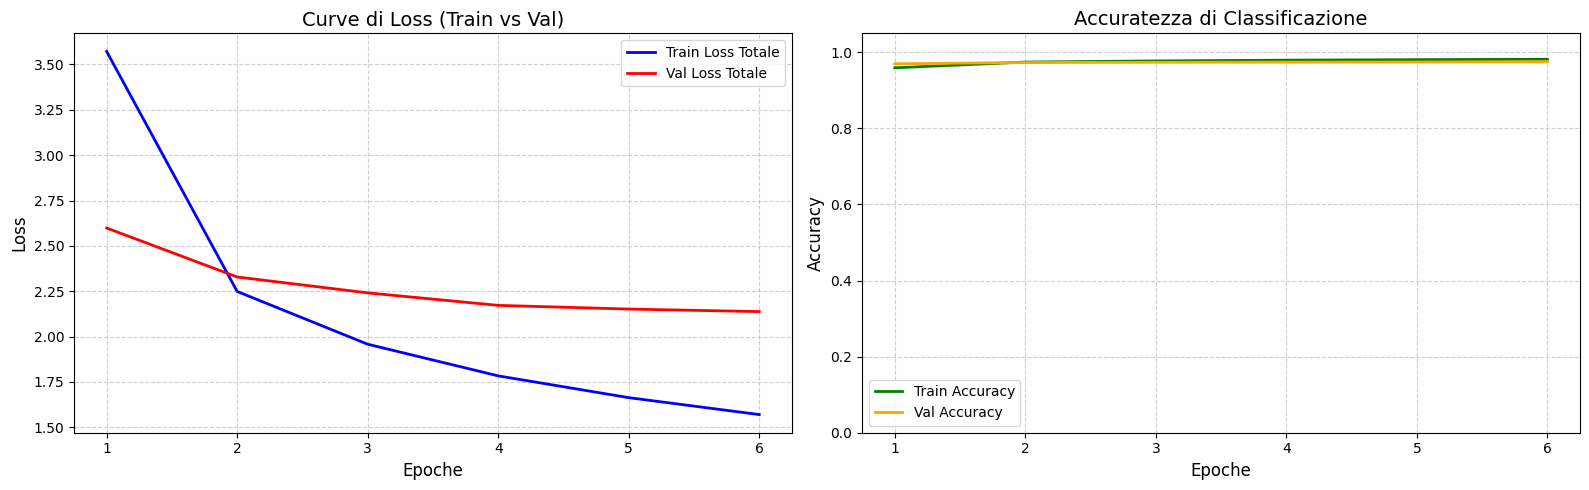

In [10]:
plot_history(b_conc_history)

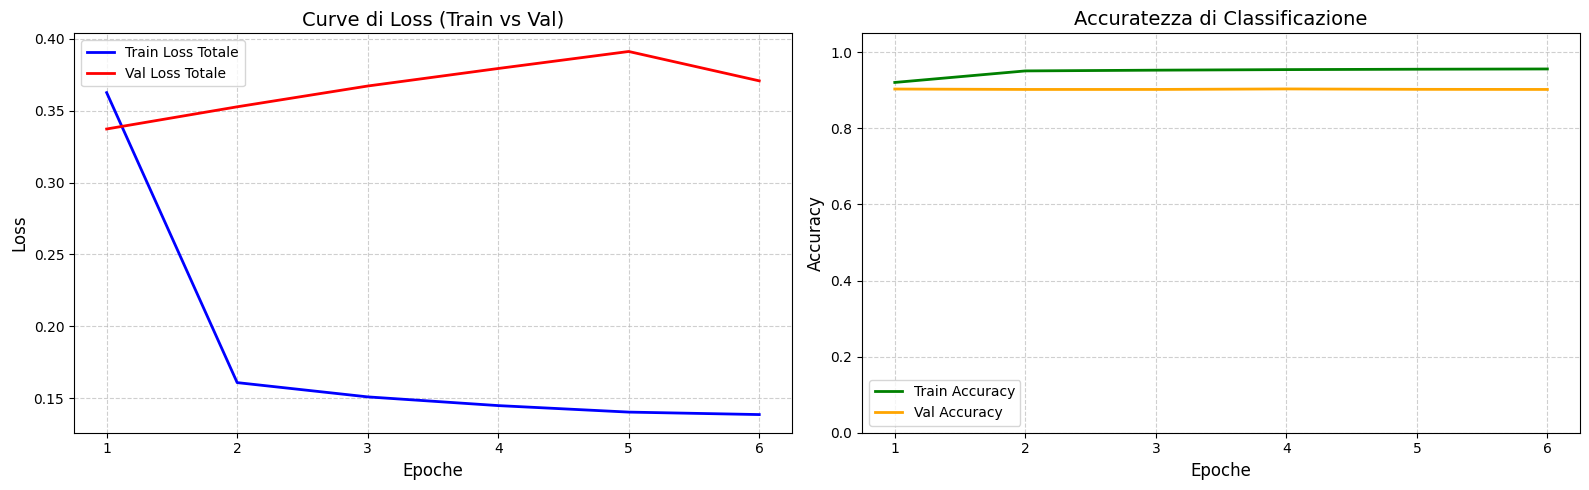

In [11]:
plot_history(b_cls_history)

#### Test

In [12]:
accuracy, preds, labels, b_conc_preds, b_conc_true, b_conc_probs = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.58% (6762/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       209
           1       0.89      0.93      0.91       170
           2       0.89      0.83      0.86        58
           3       0.77      0.79      0.78        38
           4       0.96      0.99      0.98       110
           5       0.94      0.92      0.93       149
           6       0.96      0.94      0.95       329
           7       0.89      0.89      0.89       207
           8       0.43      0.43      0.43        35
           9       0.87      0.82      0.85       100

   micro avg       0.89      0.90      0.90      1405
   macro avg       0.84      0.85      0.85      1405
weighted avg       0.89      0.90      0.90      1405



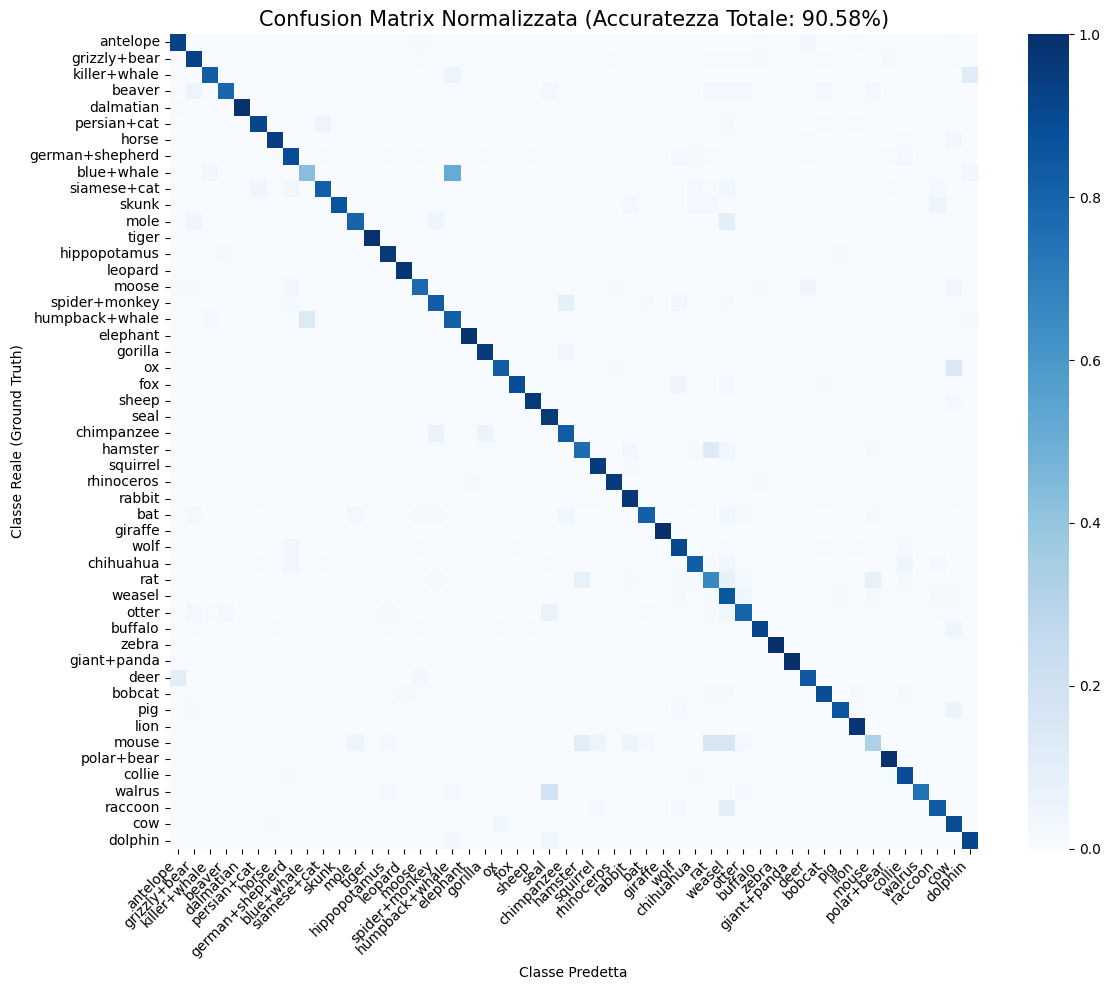


Analisi degli Errori Principali:
 - 29 volte: 'deer' è stato scambiato per 'antelope'
 - 21 volte: 'ox' è stato scambiato per 'cow'
 - 20 volte: 'hamster' è stato scambiato per 'rat'
 - 19 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 18 volte: 'blue+whale' è stato scambiato per 'humpback+whale'


In [13]:
plot_test_results(accuracy, preds, labels, class_names=classes)

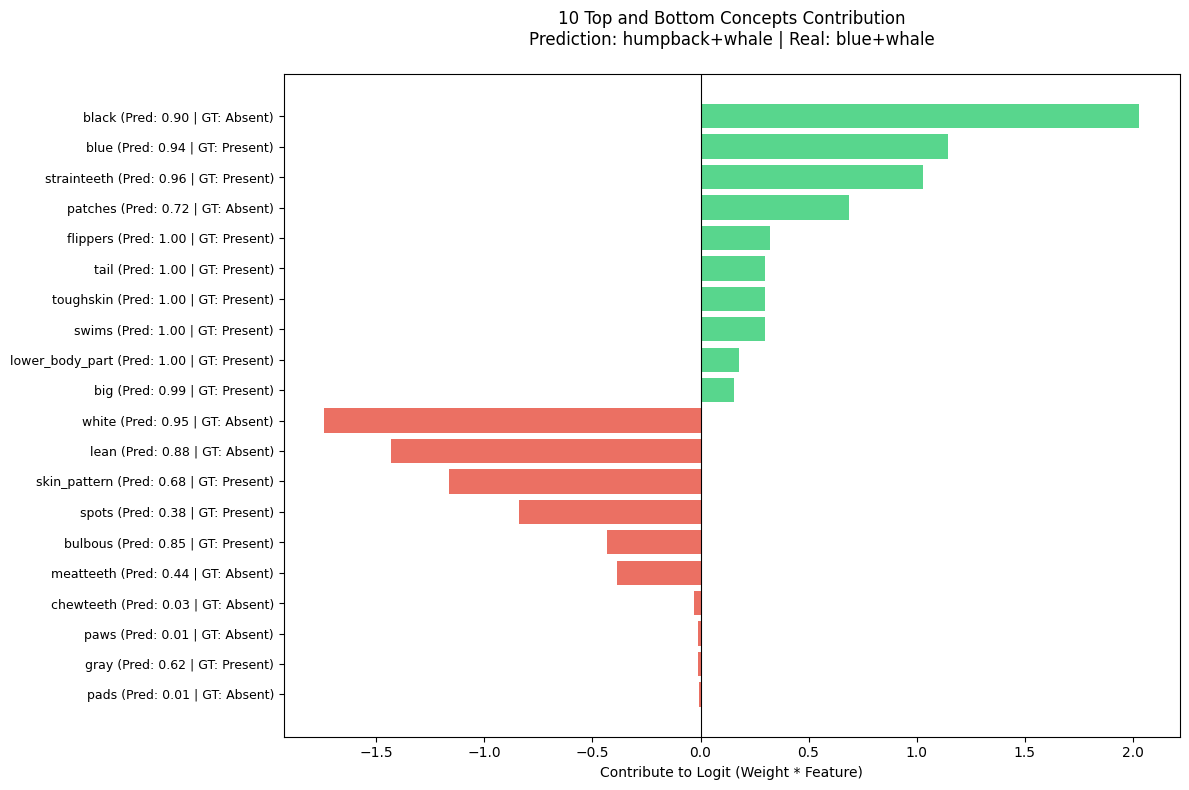

False

In [14]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="blue+whale"
)

### CBM with cond prob distrib

#### Train

In [15]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Esecuzione auto-detect dell'indicizzazione delle label...
-> Risultato: Dataset 1-INDEXED (Verrà sottratto 1 a ogni batch)

Loss: 3.5510 | Acc: 95.9528 || Val Loss: 2.5742 | Val Acc: 97.0228
Loss: 2.2539 | Acc: 97.4214 || Val Loss: 2.3628 | Val Acc: 97.2376
Loss: 1.9509 | Acc: 97.7543 || Val Loss: 2.2114 | Val Acc: 97.4187
Loss: 1.7825 | Acc: 97.9473 || Val Loss: 2.1955 | Val Acc: 97.4294
Loss: 1.6617 | Acc: 98.0804 || Val Loss: 2.0954 | Val Acc: 97.5682
Loss: 1.5711 | Acc: 98.1804 || Val Loss: 2.1350 | Val Acc: 97.4926

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=0.680, Acc=89.4% | VAL: Loss=0.381, Acc=90.4%
Epoca   2/6 | TRAIN: Loss=0.203, Acc=94.8% | VAL: Loss=0.335, Acc=90.6%
Epoca   3/6 | TRAIN: Loss=0.169, Acc=95.1% | VAL: Loss=0.329, Acc=90.7%
Epoca   4/6 | TRAIN: Loss=0.155, Acc=95.3% | VAL: Loss=0.323, Acc=90.7%
Epoca   5/6 | TRAIN: Loss=0

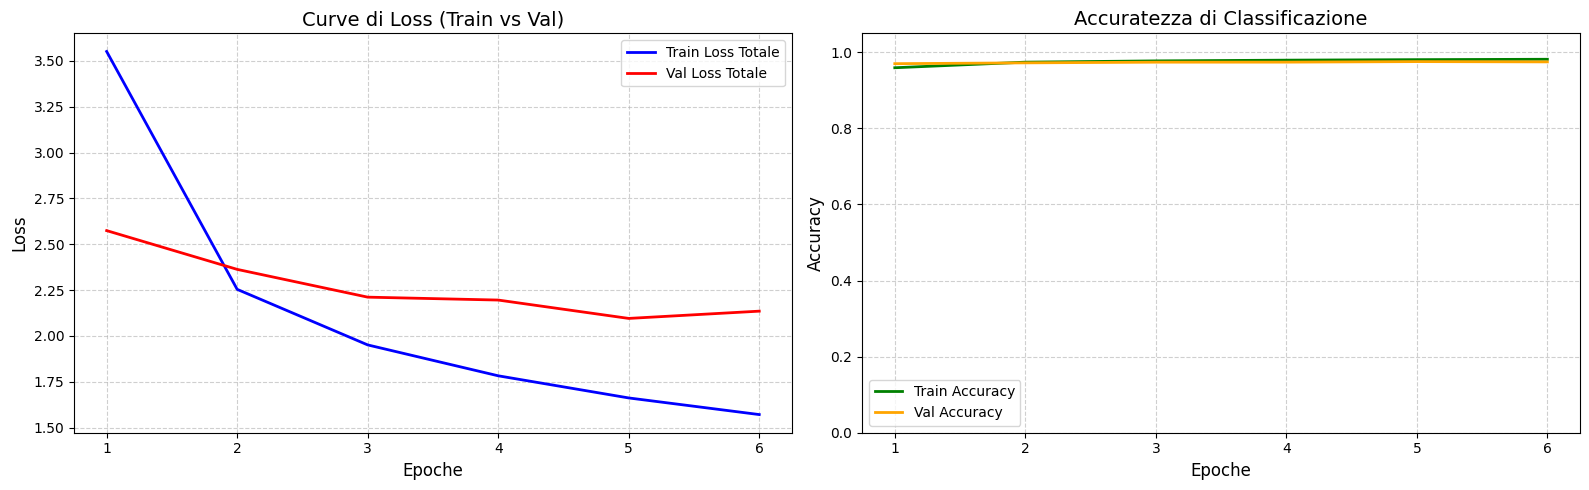

In [16]:
plot_history(cp_conc_history)

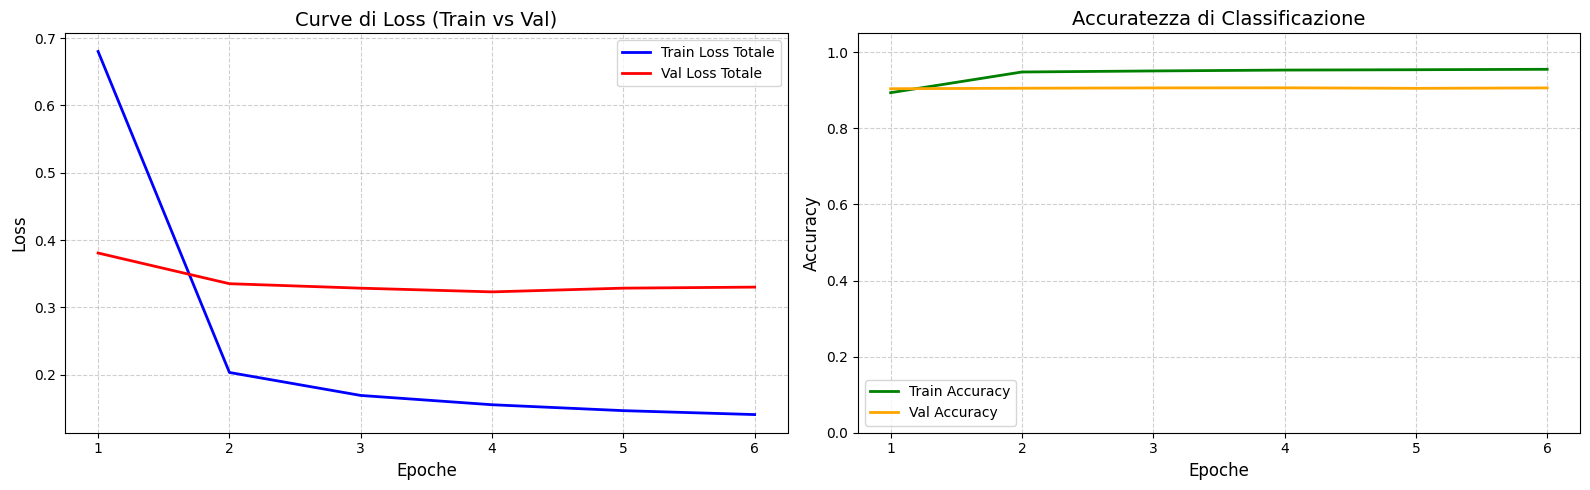

In [17]:
plot_history(cp_cls_history)

#### Test

In [18]:
cp_accuracy, cp_preds, cp_labels, cp_conc_preds, cp_conc_true, cp_conc_probs = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.77% (6776/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       209
           1       0.85      0.96      0.90       170
           2       0.90      0.79      0.84        58
           3       0.71      0.79      0.75        38
           4       0.94      0.97      0.96       110
           5       0.89      0.95      0.92       149
           6       0.93      0.95      0.94       329
           7       0.90      0.88      0.89       207
           8       0.38      0.23      0.29        35
           9       0.90      0.81      0.85       100

   micro avg       0.89      0.89      0.89      1405
   macro avg       0.83      0.82      0.82      1405
weighted avg       0.88      0.89      0.89      1405



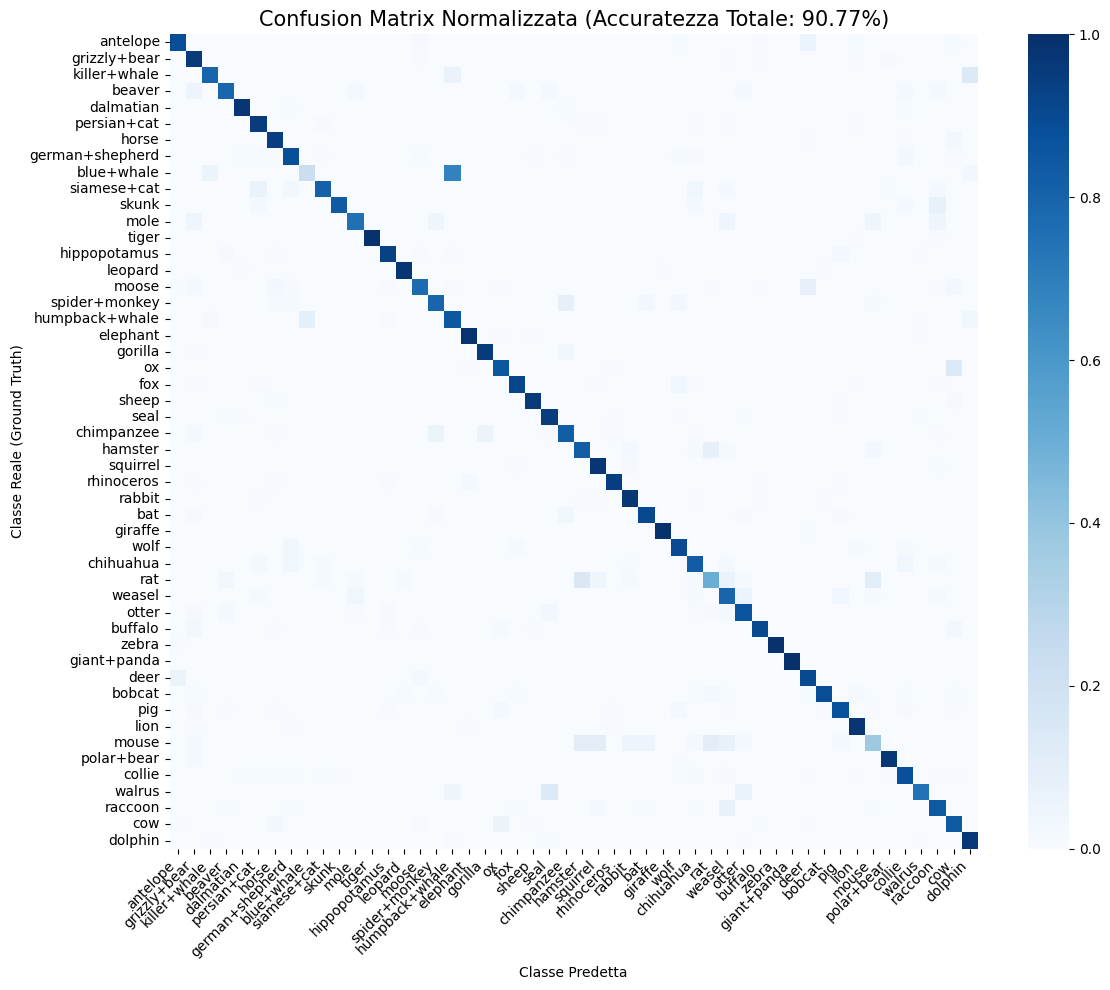


Analisi degli Errori Principali:
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 15 volte: 'cow' è stato scambiato per 'ox'
 - 15 volte: 'deer' è stato scambiato per 'antelope'
 - 13 volte: 'humpback+whale' è stato scambiato per 'blue+whale'


In [19]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

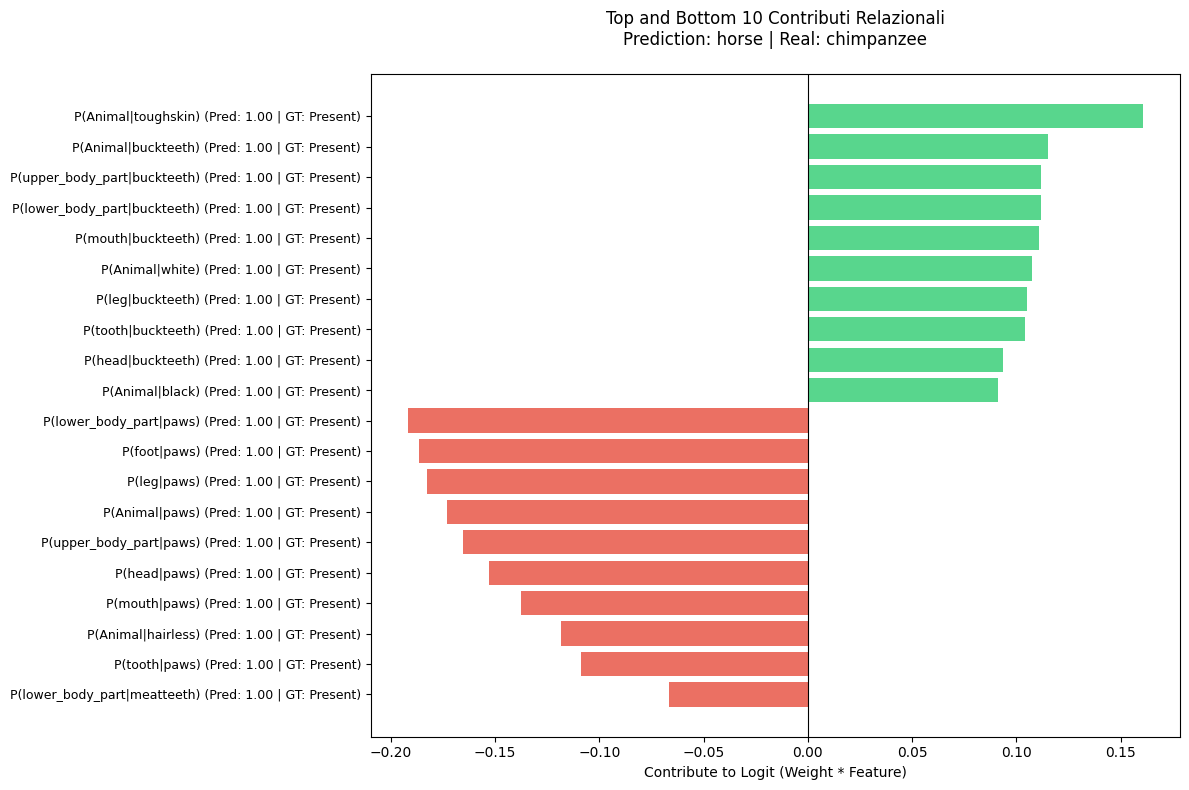

False

In [20]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [21]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Esecuzione auto-detect dell'indicizzazione delle label...
-> Risultato: Dataset 1-INDEXED (Verrà sottratto 1 a ogni batch)

Loss: 3.5744 | Acc: 95.9297 || Val Loss: 2.5810 | Val Acc: 97.0121
Loss: 2.2463 | Acc: 97.4365 || Val Loss: 2.3357 | Val Acc: 97.2392
Loss: 1.9538 | Acc: 97.7428 || Val Loss: 2.2749 | Val Acc: 97.3292
Loss: 1.7832 | Acc: 97.9389 || Val Loss: 2.1577 | Val Acc: 97.4883
Loss: 1.6592 | Acc: 98.0705 || Val Loss: 2.1467 | Val Acc: 97.4980
Loss: 1.5664 | Acc: 98.1987 || Val Loss: 2.1595 | Val Acc: 97.5028

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=1.838, Acc=74.4% | VAL: Loss=0.936, Acc=87.4%
Epoca   2/6 | TRAIN: Loss=0.586, Acc=92.7% | VAL: Loss=0.540, Acc=89.1%
Epoca   3/6 | TRAIN: Loss=0.355, Acc=93.8% | VAL: Loss=0.425, Acc=90.2%
Epoca   4/6 | TRAIN: Loss=0.271, Acc=94.5% | VAL: Loss=0.374, Acc=90.3%
Epoca   5/6 | TRAIN: Loss=0

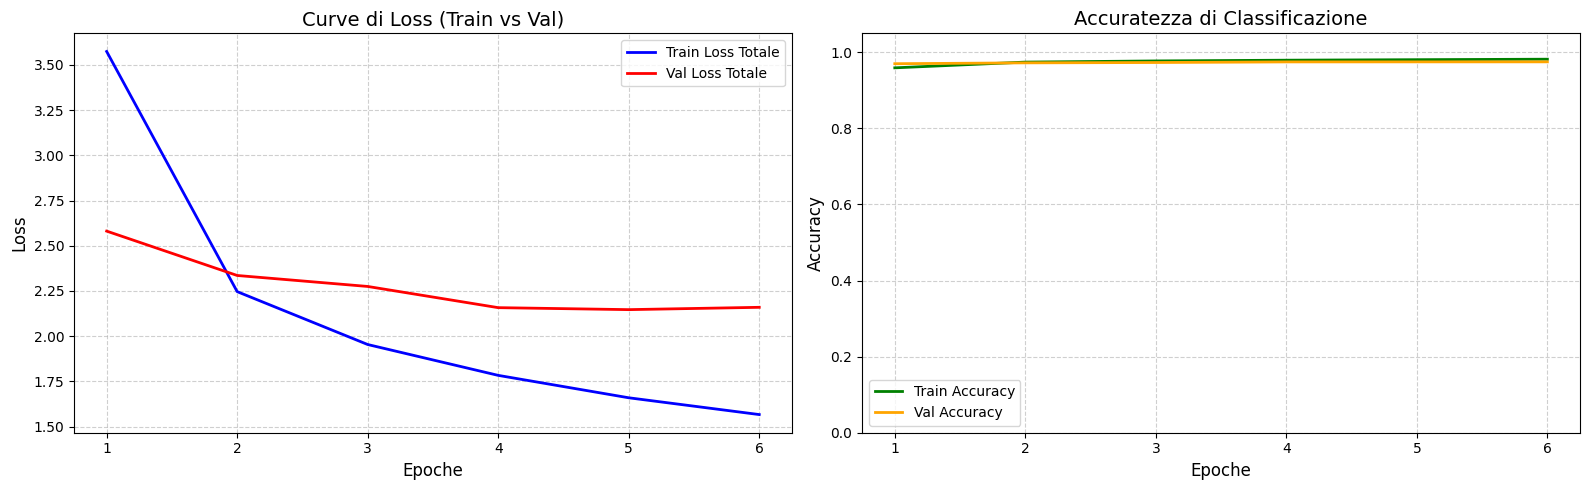

In [22]:
from src.utils.plot import plot_history
plot_history(c_conc_history)

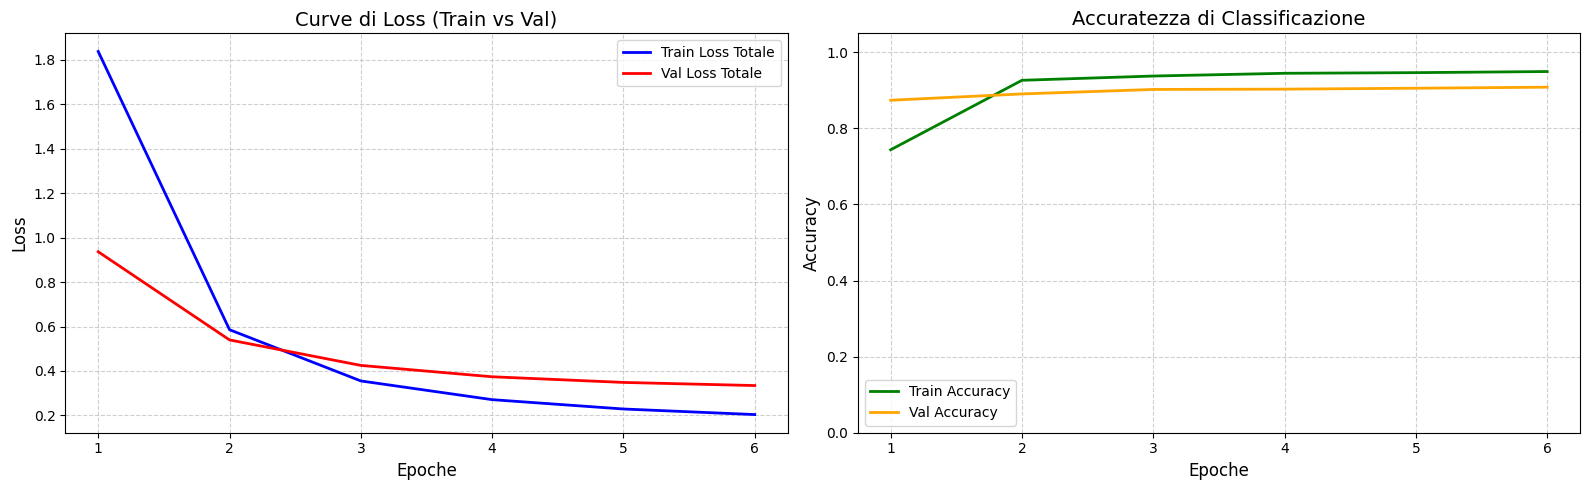

In [23]:
plot_history(c_cls_history)

In [24]:
c_accuracy, c_preds, c_labels, c_conc_preds, c_conc_true, c_conc_probs = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.90% (6786/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       209
           1       0.87      0.94      0.91       170
           2       0.90      0.78      0.83        58
           3       0.77      0.71      0.74        38
           4       0.94      0.99      0.96       110
           5       0.93      0.93      0.93       149
           6       0.96      0.94      0.95       329
           7       0.89      0.89      0.89       207
           8       0.33      0.03      0.05        35
           9       0.79      0.88      0.83       100

   micro avg       0.90      0.89      0.89      1405
   macro avg       0.83      0.80      0.80      1405
weighted avg       0.89      0.89      0.89      1405



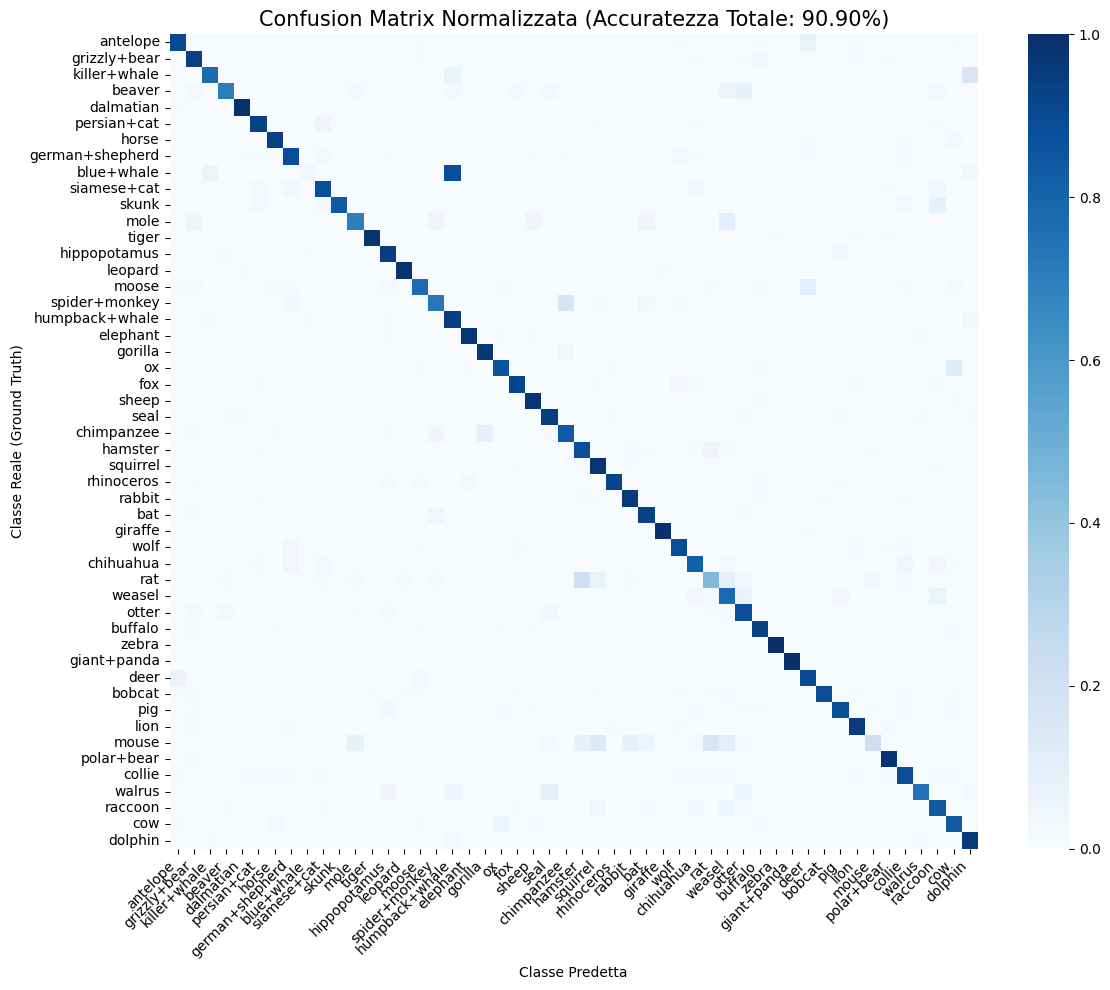


Analisi degli Errori Principali:
 - 31 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 17 volte: 'ox' è stato scambiato per 'cow'
 - 17 volte: 'deer' è stato scambiato per 'antelope'
 - 16 volte: 'cow' è stato scambiato per 'ox'
 - 15 volte: 'antelope' è stato scambiato per 'deer'


In [25]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

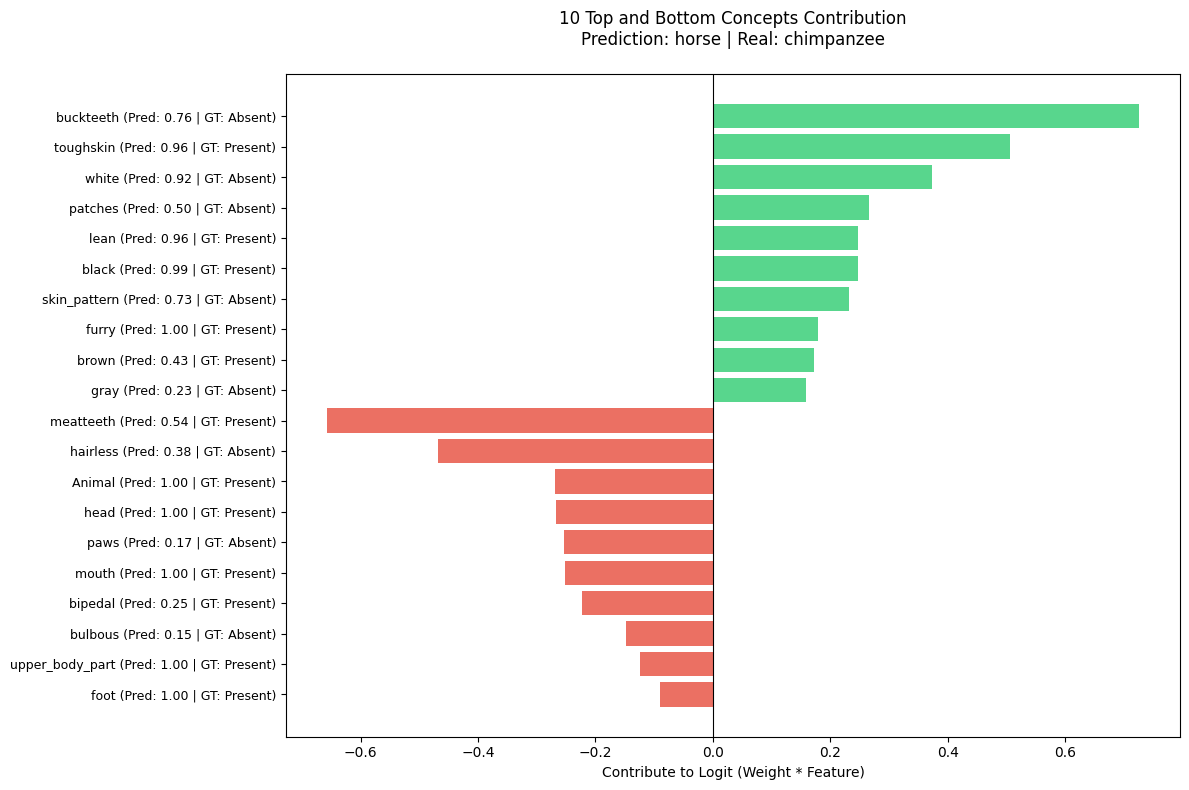

False

In [31]:
from src.CHM.interpretation import explain_prediction
info = 'concepts'
explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM ALL

#### Train

In [27]:
info = "all"
bipolar = True
a_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
a_optimizer = torch.optim.Adam(a_cls.parameters(), lr=0.001)
a_criterion = nn.CrossEntropyLoss()

a_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
a_concept_optimizer = torch.optim.Adam(a_concept_predictor.parameters(), lr=0.001)
a_concept_criterion = nn.BCEWithLogitsLoss()

a_conc_history, a_cls_history = sequential_training(
    a_cls,
    a_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    a_optimizer,  
    a_concept_optimizer,
    a_criterion,
    a_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Esecuzione auto-detect dell'indicizzazione delle label...
-> Risultato: Dataset 1-INDEXED (Verrà sottratto 1 a ogni batch)

Loss: 3.5571 | Acc: 95.9270 || Val Loss: 2.6086 | Val Acc: 96.9981
Loss: 2.2465 | Acc: 97.4402 || Val Loss: 2.3142 | Val Acc: 97.2912
Loss: 1.9562 | Acc: 97.7523 || Val Loss: 2.2120 | Val Acc: 97.3978
Loss: 1.7819 | Acc: 97.9411 || Val Loss: 2.1705 | Val Acc: 97.4717
Loss: 1.6595 | Acc: 98.0781 || Val Loss: 2.1487 | Val Acc: 97.4867
Loss: 1.5606 | Acc: 98.2006 || Val Loss: 2.1079 | Val Acc: 97.5350

========== FASE 2: Addestramento Classificatore Sequenziale (c_pred -> y) ==========
Epoca   1/6 | TRAIN: Loss=0.601, Acc=89.7% | VAL: Loss=0.363, Acc=90.2%
Epoca   2/6 | TRAIN: Loss=0.189, Acc=94.9% | VAL: Loss=0.333, Acc=90.8%
Epoca   3/6 | TRAIN: Loss=0.162, Acc=95.2% | VAL: Loss=0.324, Acc=90.7%
Epoca   4/6 | TRAIN: Loss=0.150, Acc=95.4% | VAL: Loss=0.321, Acc=90.5%
Epoca   5/6 | TRAIN: Loss=0

#### Test

In [28]:
a_accuracy, a_preds, a_labels, a_conc_preds, a_conc_true, a_conc_probs = test_sequential_cbm(
    a_cls,
    a_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.50% (6756/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       209
           1       0.88      0.94      0.91       170
           2       0.90      0.79      0.84        58
           3       0.50      0.74      0.60        38
           4       0.96      0.98      0.97       110
           5       0.90      0.97      0.94       149
           6       0.96      0.93      0.94       329
           7       0.87      0.90      0.88       207
           8       0.47      0.20      0.28        35
           9       0.90      0.83      0.86       100

   micro avg       0.88      0.90      0.89      1405
   macro avg       0.82      0.82      0.81      1405
weighted avg       0.88      0.90      0.89      1405

